In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

## Load UHI Data

In [ ]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()

In [ ]:
# Step 1: Apply illumination correction
cube.apply_illumination_correction_v3()

In [ ]:
# Step 2: Apply alignment adjustment
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

In [ ]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

In [ ]:
# Define analysis lines - ADJUSTED for track range (576-1566)
# Place lines within visible data range
line1 = [(410, 710), (940, 780)]
line2 = [(340, 1030), (340, 1210)]
line3 = [(250, 890), (250, 990)]
line4 = [(300, 1358), (300, 1458)]

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]

# Plot RGB georef - EXACT wavelengths: 677nm (R), 610nm (G), 490nm (B)
# plot_georef will find the CLOSEST available wavelength to these targets
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    apply_alignment_shift=True,
)

# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)

cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=True,
)

In [ ]:
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[0],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
    figsize=(10, 10),
)

# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[1],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
    figsize=(10, 10),
)
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[2],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
    figsize=(10, 10),
)
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[3],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
    figsize=(10, 10),
)

# below is shit code for 057, not relevant, skip to 028 processing at the bottom

In [ ]:
# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=0,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=10,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)
# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=0,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=True,
)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=True,
    sparse_show_markers=False,
)

# below i started testing different smoothing

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

## Test New Features: Gaussian Smoothing & L2 Normalization

**⚠️ IMPORTANT: Restart kernel and re-run cells 1-6 before running tests below!**

Testing the new parameters:
- `smoothing_method="gaussian"` with `gaussian_sigma`
- `normalization_method="l2"` for L2 normalization

New features added to both `plot_line_intensity_profile` and `plot_wavelength_comparison`!

In [ ]:
# Test 1: Gaussian smoothing with different sigma values
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",  # NEW: Gaussian smoothing
    gaussian_sigma=10.0,  # NEW: Sigma parameter
    use_corrected=True,
)
print("\n✅ Test 1 complete: Gaussian smoothing with sigma=2.0")

In [ ]:
# Test 2: Compare Gaussian (sigma=5.0) vs Moving Average
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left: Gaussian smoothing
plt.sca(ax1)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=5.0,
    use_corrected=True,
)
ax1.set_title("Gaussian Smoothing (σ=5.0)", fontsize=14, fontweight="bold")

# Right: Moving average
plt.sca(ax2)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="moving_average",
    moving_average_percent=20,
    use_corrected=True,
)
ax2.set_title("Moving Average (20%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n✅ Test 2 complete: Gaussian vs Moving Average comparison")

In [ ]:
# Test 3: L2 Normalization
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=2.0,
    normalize_intensities=True,
    normalization_method="l2",  # NEW: L2 normalization (unit vector)
    use_corrected=True,
)
print("\n✅ Test 3 complete: L2 normalization")
print("⚠️  Note: L2 normalization makes the intensity vector have Euclidean norm = 1")

In [ ]:
# # Test 4: Compare all normalization methods
# fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# normalization_methods = [
#     ("minmax", "MinMax [0-1]"),
#     ("zscore", "Z-Score"),
#     ("mean", "Mean-Relative"),
#     ("l2", "L2 (Unit Vector)"),
# ]

# for idx, (method, title) in enumerate(normalization_methods):
#     ax = axes[idx // 2, idx % 2]
#     plt.sca(ax)

#     cube.plot_wavelength_comparison(
#         line=lines[0],
#         wavelength_ranges=[677, 610, 490],
#         smoothing_method="gaussian",
#         gaussian_sigma=2.0,
#         normalize_intensities=True,
#         normalization_method=method,
#         use_corrected=True,
#     )
#     ax.set_title(f"{title} Normalization", fontsize=14, fontweight="bold")

# plt.tight_layout()
# plt.show()
# print("\n✅ Test 4 complete: All normalization methods compared")

In [ ]:
# Test 5: Line intensity profiles with Gaussian smoothing
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    wavelength_range="all",
    smoothing_method="gaussian",  # NEW: Use Gaussian instead of moving average
    gaussian_sigma=3.0,  # NEW: Sigma parameter
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
)
print("\n✅ Test 5 complete: Line intensity profiles with Gaussian smoothing")

# 🆕 Test New Sparse Sampling Feature

**Purpose:** Compare old (oversampling/duplication) vs new (sparse sampling) methods

The new `use_sparse_sampling=True` (now default) avoids pixel duplication for short lines!

In [ ]:
# Test: Compare OLD (oversampling) vs NEW (sparse sampling)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# LEFT: OLD METHOD (oversampling with duplication)
plt.sca(ax1)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=False,  # OLD: causes pixel duplication
    figsize=(12, 8),
)
ax1.set_title(
    "❌ OLD: Oversampling (duplicates pixels in short lines)",
    fontsize=14,
    fontweight="bold",
    color="red",
)
ax1.set_xlabel("Sample Index (artificially extended for short lines)")

# RIGHT: NEW METHOD (sparse sampling, no duplication)
plt.sca(ax2)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,  # NEW: preserves original pixels
    sparse_normalize_x=True,  # Scale X so all lines end at same position
    sparse_smoothing="before",  # Smooth before sparse placement
    figsize=(12, 8),
)
ax2.set_title(
    "✅ NEW: Sparse Sampling (preserves original data)",
    fontsize=14,
    fontweight="bold",
    color="green",
)
ax2.set_xlabel("Normalized Distance (no pixel duplication)")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📊 LINE LENGTHS:")
for i, line in enumerate(lines, 1):
    (s1, t1), (s2, t2) = line
    length = max(abs(t2 - t1), abs(s2 - s1)) + 1
    print(f"   Line {i}: {length} pixels")
print("=" * 80)
print(
    "\n⚠️  OLD METHOD: All lines resampled to 540 points → short lines have duplicated pixels"
)
print(
    "✅ NEW METHOD: Each line keeps its actual pixel count → no artificial duplication"
)

In [ ]:
# Test: Compare different smoothing options with sparse sampling
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

smoothing_options = [
    ("before", "Smooth BEFORE sparse placement (default)"),
    ("none", "NO smoothing (matplotlib draws straight lines)"),
    ("after", "Smooth AFTER sparse placement (experimental)"),
]

for idx, (smooth_mode, title) in enumerate(smoothing_options):
    plt.sca(axes[idx])
    cube.plot_line_intensity_profile(
        perimeter_line=lines,
        use_average=True,
        moving_average_percent=20,
        wavelength_range="all",
        use_corrected=True,
        line_labels=labels,
        line_colors=colors,
        use_sparse_sampling=True,
        sparse_normalize_x=True,
        sparse_smoothing=smooth_mode,  # Test different smoothing modes
        figsize=(10, 8),
    )
    axes[idx].set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📝 SMOOTHING OPTIONS EXPLAINED:")
print("=" * 80)
print("1️⃣  'before' (default): Apply smoothing to original pixel values")
print("    → Smooth data, then place at sparse X positions")
print("    → Best for preserving features while reducing noise")
print()
print("2️⃣  'none': No smoothing applied")
print("    → Raw pixel values, matplotlib connects with straight lines")
print("    → Most honest representation, shows actual sampling")
print()
print("3️⃣  'after': Apply smoothing after sparse placement (NOT RECOMMENDED)")
print("    → Place sparse points, then smooth in X-space")
print("    → May create artifacts, use only for experimentation")
print("=" * 80)

In [ ]:
# Test: X-axis normalization options
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# LEFT: X-axis normalized (all lines end at same position)
plt.sca(ax1)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,
    sparse_normalize_x=True,  # Scale X so all end at same position
    sparse_smoothing="before",
    figsize=(12, 8),
)
ax1.set_title(
    "Normalized X-axis (all lines end at same position)", fontsize=14, fontweight="bold"
)
ax1.set_xlabel("Normalized Distance")

# RIGHT: X-axis NOT normalized (lines end at actual length)
plt.sca(ax2)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,
    sparse_normalize_x=False,  # Lines end at their actual length
    sparse_smoothing="before",
    figsize=(12, 8),
)
ax2.set_title(
    "Actual X-axis (shorter lines end earlier)", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Actual Distance (pixels)")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📏 X-AXIS SCALING OPTIONS:")
print("=" * 80)
print("✅ sparse_normalize_x=True (default):")
print("   → All lines scaled to end at same X position")
print("   → Better for visual comparison")
print("   → X-axis shows 'normalized distance'")
print()
print("📐 sparse_normalize_x=False:")
print("   → Lines end at their actual pixel length")
print("   → More honest about spatial extent")
print("   → Shorter lines visibly end earlier")
print("=" * 80)

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---
---
---
---
---
---
---
---
---
---
---


# Transect 028 Crop Lines Analysis

Load transect 028 data (same preprocessing as transect 057) and create intensity profile lines for cropped regions.

In [ ]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

# 🔬 DETAILED MECHANISM VERIFICATION

This section traces through the EXACT pixel sampling and plotting mechanism to confirm:
1. How pixels along a line are selected and indexed
2. How wavelength values are extracted for each pixel
3. How the horizontal axis (sample index) relates to pixel positions

In [ ]:
# import numpy as np

# # =============================================================================
# # STEP-BY-STEP MECHANISM VERIFICATION
# # =============================================================================
# print("=" * 80)
# print("VERIFYING THE EXACT MECHANISM OF LINE INTENSITY PROFILING")
# print("=" * 80)

# # Let's use Bomb 2 from transect 028 as our example
# # From the notebook above, Bomb 2 line definition is:
# bomb2_region = crop_regions_028[1]  # {"track": 1258, "slit": 250, "label": "Bomb 2"}
# bomb2_line_local = crop_lines_028["Bomb 2"]  # [(10, 65), (420, 65)]

# print(f"\n📍 EXAMPLE LINE: Bomb 2")
# print(
#     f"   Crop region center: track={bomb2_region['track']}, slit={bomb2_region['slit']}"
# )
# print(f"   Line coordinates (LOCAL crop space): {bomb2_line_local}")

# # Convert to global coordinates (same as the monkeypatch function does)
# track_center = bomb2_region["track"]
# slit_center = bomb2_region["slit"]
# crop_width = 500
# crop_height = 125
# track_min = track_center - crop_height // 2
# slit_min = slit_center - crop_width // 2

# x1_local, y1_local = bomb2_line_local[0]
# x2_local, y2_local = bomb2_line_local[1]

# slit1_global = slit_min + x1_local
# track1_global = track_min + y1_local
# slit2_global = slit_min + x2_local
# track2_global = track_min + y2_local

# print(f"\n📍 GLOBAL COORDINATES:")
# print(f"   START point: (slit={slit1_global}, track={track1_global})")
# print(f"   END point:   (slit={slit2_global}, track={track2_global})")

# # =============================================================================
# # STEP 1: PIXEL SAMPLING ALONG THE LINE
# # =============================================================================
# print(f"\n" + "=" * 80)
# print(f"STEP 1: HOW PIXELS ARE SAMPLED ALONG THE LINE")
# print(f"=" * 80)

# # Calculate line length (this is what the function does)
# line_length = (
#     max(abs(track2_global - track1_global), abs(slit2_global - slit1_global)) + 1
# )

# print(f"\n📏 Line length calculation:")
# print(
#     f"   track_diff = |{track2_global} - {track1_global}| = {abs(track2_global - track1_global)}"
# )
# print(
#     f"   slit_diff = |{slit2_global} - {slit1_global}| = {abs(slit2_global - slit1_global)}"
# )
# print(
#     f"   line_length = max({abs(track2_global - track1_global)}, {abs(slit2_global - slit1_global)}) + 1 = {line_length}"
# )

# # Generate sampling points using np.linspace (exactly as the function does)
# track_indices = np.linspace(track1_global, track2_global, line_length, dtype=int)
# slit_indices = np.linspace(slit1_global, slit2_global, line_length, dtype=int)

# print(
#     f"\n📍 PIXEL SAMPLING using np.linspace({track1_global}, {track2_global}, {line_length}):"
# )
# print(f"   This creates {line_length} evenly-spaced indices from START to END")
# print(f"\n   First 5 sampled pixels:")
# for i in range(min(5, line_length)):
#     print(f"   Index {i:3d}: (slit={slit_indices[i]:4d}, track={track_indices[i]:4d})")

# print(f"\n   Middle pixels (around index {line_length//2}):")
# mid = line_length // 2
# for i in range(max(0, mid - 2), min(line_length, mid + 3)):
#     print(f"   Index {i:3d}: (slit={slit_indices[i]:4d}, track={track_indices[i]:4d})")

# print(f"\n   Last 5 sampled pixels:")
# for i in range(max(0, line_length - 5), line_length):
#     print(f"   Index {i:3d}: (slit={slit_indices[i]:4d}, track={track_indices[i]:4d})")

# # =============================================================================
# # STEP 2: EXTRACTING WAVELENGTH VALUES FOR EACH PIXEL
# # =============================================================================
# print(f"\n" + "=" * 80)
# print(f"STEP 2: EXTRACTING WAVELENGTH VALUES FOR EACH SAMPLED PIXEL")
# print(f"=" * 80)

# # Get the data (use corrected if available)
# if hasattr(cube_028, "data_corrected"):
#     data = cube_028.data_corrected
# else:
#     data = cube_028.data

# print(f"\n📊 Data cube shape: {data.shape}")
# print(
#     f"   (track_pixels, slit_pixels, wavelengths) = ({data.shape[0]}, {data.shape[1]}, {data.shape[2]})"
# )

# # For each sampled pixel, extract intensity values
# print(f"\n   For each sampled pixel at index i:")
# print(f"   → Access data[track_indices[i], slit_indices[i], :]")
# print(f"   → This gives all wavelength values for that spatial pixel")

# # Example: Extract intensities for first few pixels
# print(f"\n   Example: First 3 pixels")
# for i in range(min(3, line_length)):
#     track_idx = track_indices[i]
#     slit_idx = slit_indices[i]
#     pixel_intensities = data[track_idx, slit_idx, :]  # All wavelengths for this pixel
#     avg_intensity = np.mean(pixel_intensities)
#     print(
#         f"   Index {i}: data[{track_idx}, {slit_idx}, :] → {len(pixel_intensities)} wavelength values"
#     )
#     print(f"            Average across wavelengths: {avg_intensity:.4f}")

# # =============================================================================
# # STEP 3: PLOTTING MECHANISM
# # =============================================================================
# print(f"\n" + "=" * 80)
# print(f"STEP 3: HOW THE PLOT IS CREATED")
# print(f"=" * 80)

# print(f"\n   The function does:")
# print(f"   1. For each pixel along the line (index 0 to {line_length-1}):")
# print(f"      - Sample pixel at (slit_indices[i], track_indices[i])")
# print(f"      - Extract wavelength values: data[track_indices[i], slit_indices[i], :]")
# print(f"      - Compute intensity (average, specific wavelength, etc.)")
# print(f"   ")
# print(f"   2. Create arrays:")
# print(f"      - x_axis = [0, 1, 2, ..., {line_length-1}]  (sample indices)")
# print(f"      - y_axis = [intensity_0, intensity_1, ..., intensity_{line_length-1}]")
# print(f"   ")
# print(f"   3. Plot: plt.plot(x_axis, y_axis)")
# print(f"      - Horizontal axis (X) = sample index (position along line)")
# print(f"      - Vertical axis (Y) = intensity value")

# # =============================================================================
# # VERIFICATION WITH ACTUAL DATA
# # =============================================================================
# print(f"\n" + "=" * 80)
# print(f"VERIFICATION: EXTRACT ACTUAL INTENSITIES")
# print(f"=" * 80)

# # Extract actual average intensities (averaging all wavelengths)
# actual_intensities = []
# for i in range(line_length):
#     track_idx = track_indices[i]
#     slit_idx = slit_indices[i]
#     pixel_all_wavelengths = data[track_idx, slit_idx, :]
#     avg_intensity = np.mean(pixel_all_wavelengths)
#     actual_intensities.append(avg_intensity)

# actual_intensities = np.array(actual_intensities)

# print(f"\n📊 Extracted {len(actual_intensities)} intensity values")
# print(f"   Min intensity: {actual_intensities.min():.4f}")
# print(f"   Max intensity: {actual_intensities.max():.4f}")
# print(f"   Mean intensity: {actual_intensities.mean():.4f}")

# # Find where minimum occurs
# min_idx = np.argmin(actual_intensities)
# print(f"\n🔍 MINIMUM INTENSITY LOCATION:")
# print(f"   Occurs at sample index: {min_idx} (out of 0-{line_length-1})")
# print(
#     f"   Corresponds to pixel: (slit={slit_indices[min_idx]}, track={track_indices[min_idx]})"
# )
# print(f"   Intensity value: {actual_intensities[min_idx]:.4f}")

# # Calculate position along line
# relative_position = min_idx / (line_length - 1) * 100
# print(f"   Relative position: {relative_position:.1f}% along the line")

# if relative_position < 30:
#     print(f"   ✅ Near START of line")
# elif relative_position > 70:
#     print(f"   ✅ Near END of line")
# else:
#     print(f"   ✅ In MIDDLE of line")

# # =============================================================================
# # SUMMARY
# # =============================================================================
# print(f"\n" + "=" * 80)
# print(f"✅ CONFIRMATION OF MECHANISM")
# print(f"=" * 80)
# print(f"\n1. LINE DEFINITION:")
# print(f"   - Start point: (slit={slit1_global}, track={track1_global})")
# print(f"   - End point:   (slit={slit2_global}, track={track2_global})")
# print(f"   - Line length: {line_length} pixels")
# print(f"\n2. PIXEL SAMPLING:")
# print(f"   - Uses np.linspace to create {line_length} evenly-spaced indices")
# print(
#     f"   - Sample index 0 → START point (slit={slit_indices[0]}, track={track_indices[0]})"
# )
# print(
#     f"   - Sample index {line_length-1} → END point (slit={slit_indices[-1]}, track={track_indices[-1]})"
# )
# print(f"   - Each index corresponds to ONE physical pixel in the image")
# print(f"\n3. WAVELENGTH EXTRACTION:")
# print(f"   - For each sampled pixel: data[track_idx, slit_idx, :]")
# print(f"   - This gives ALL wavelength values for that pixel")
# print(f"   - Intensity computed by averaging/selecting wavelengths")
# print(f"\n4. PLOTTING:")
# print(f"   - X-axis (horizontal): Sample index (0 to {line_length-1})")
# print(f"   - Y-axis (vertical): Intensity value")
# print(f"   - Each point on plot represents ONE pixel along the line")
# print(f"\n5. RELATIONSHIP:")
# print(
#     f"   Sample index i → Pixel (slit_indices[i], track_indices[i]) → Intensity value"
# )
# print(f"\n✅ YES, THIS IS EXACTLY WHAT YOU DESCRIBED!")
# print("=" * 80)

In [ ]:
# # Create a visual representation of the sampling mechanism
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# # ===== PLOT 1: Show the actual intensity profile =====
# ax1 = axes[0]
# ax1.plot(
#     np.arange(line_length),
#     actual_intensities,
#     "b-",
#     linewidth=2,
#     label="Intensity profile",
# )
# ax1.scatter(
#     np.arange(line_length),
#     actual_intensities,
#     c="blue",
#     s=20,
#     alpha=0.5,
#     label="Sampled pixels",
# )

# # Mark the minimum
# ax1.scatter(
#     min_idx,
#     actual_intensities[min_idx],
#     c="red",
#     s=200,
#     marker="*",
#     label=f"Minimum (index {min_idx})",
#     zorder=10,
# )

# ax1.set_xlabel("Sample Index (position along line)", fontsize=12, fontweight="bold")
# ax1.set_ylabel("Average Intensity", fontsize=12, fontweight="bold")
# ax1.set_title(
#     f"Intensity Profile: Bomb 2 Line ({line_length} pixels sampled)",
#     fontsize=14,
#     fontweight="bold",
# )
# ax1.grid(True, alpha=0.3)
# ax1.legend(fontsize=10)

# # Add annotations
# ax1.annotate(
#     f"START\n(slit={slit1_global}, track={track1_global})",
#     xy=(0, actual_intensities[0]),
#     xytext=(20, actual_intensities[0] + 0.02),
#     arrowprops=dict(arrowstyle="->", color="green", lw=2),
#     fontsize=10,
#     fontweight="bold",
#     color="green",
# )

# ax1.annotate(
#     f"END\n(slit={slit2_global}, track={track2_global})",
#     xy=(line_length - 1, actual_intensities[-1]),
#     xytext=(line_length - 40, actual_intensities[-1] + 0.02),
#     arrowprops=dict(arrowstyle="->", color="orange", lw=2),
#     fontsize=10,
#     fontweight="bold",
#     color="orange",
# )

# # ===== PLOT 2: Show mapping from sample index to pixel coordinates =====
# ax2 = axes[1]

# # Plot slit coordinate vs sample index
# ax2.plot(
#     np.arange(line_length),
#     slit_indices,
#     "g-",
#     linewidth=2,
#     label="Slit coordinate",
#     marker="o",
#     markersize=3,
# )
# ax2.plot(
#     np.arange(line_length),
#     track_indices,
#     "orange",
#     linewidth=2,
#     label="Track coordinate",
#     marker="s",
#     markersize=3,
# )

# ax2.set_xlabel(
#     "Sample Index (X-axis in intensity plot)", fontsize=12, fontweight="bold"
# )
# ax2.set_ylabel("Pixel Coordinate (global)", fontsize=12, fontweight="bold")
# ax2.set_title(
#     "Mapping: Sample Index → Pixel Coordinates", fontsize=14, fontweight="bold"
# )
# ax2.grid(True, alpha=0.3)
# ax2.legend(fontsize=10)

# # Add text box explaining the mapping
# textstr = f"""HOW IT WORKS:
# 1. Line defined: START({slit1_global},{track1_global}) → END({slit2_global},{track2_global})
# 2. Sample {line_length} evenly-spaced pixels using np.linspace
# 3. Sample index i → Pixel (slit_indices[i], track_indices[i])
# 4. Extract intensity: data[track_indices[i], slit_indices[i], :]
# 5. Plot: X-axis = sample index, Y-axis = intensity"""

# props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
# ax2.text(
#     0.02,
#     0.98,
#     textstr,
#     transform=ax2.transAxes,
#     fontsize=9,
#     verticalalignment="top",
#     bbox=props,
#     family="monospace",
# )

# plt.tight_layout()
# plt.show()

# print("\n" + "=" * 80)
# print("📊 VISUAL VERIFICATION COMPLETE")
# print("=" * 80)
# print("\nThe top plot shows:")
# print("  - X-axis (horizontal): Sample index (0 to", line_length - 1, ")")
# print("  - Y-axis (vertical): Intensity value")
# print("  - Blue line: Intensity profile along the line")
# print("  - Red star: Location of minimum intensity")
# print("\nThe bottom plot shows:")
# print("  - How sample index maps to actual pixel coordinates")
# print("  - Green line: Slit coordinate changes along line")
# print("  - Orange line: Track coordinate changes along line")
# print("  - For Bomb 2: track is constant (horizontal line)")
# print("  -              slit increases from", slit1_global, "to", slit2_global)
# print("=" * 80)

In [ ]:
# Load transect 028 (same preprocessing as transect 057)
transect_028 = load_transect(config.TRANSECT_028_OUTPUT)
transect_028.list_files()

# Select all 5 files from transect 028
cube_028 = transect_028.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
cube_028.describe()

In [ ]:
# Apply illumination correction v3 (same as transect 057)
cube_028.apply_illumination_correction_v2()

In [ ]:
# Apply wavelength filter (same as transect 057)
cube_028.apply_wavelength_filter(wavelength_range=(490, 700))
# Note: 028 does NOT need alignment adjustment (only 057 needs it)

## Define Crop Regions and Lines (Local Coordinates)

Lines are defined in LOCAL crop coordinates:
- X-axis: 0 to crop_width (default 500 pixels)
- Y-axis: 0 to crop_height (default 125 pixels for aspect_ratio=4)

In [ ]:
# Crop regions from notebook 8 (global track/slit coordinates)
crop_regions_028 = [
    {"track": 5160, "slit": 613, "label": "Bomb 1"},
    {"track": 1258, "slit": 250, "label": "Bomb 2"},
    {"track": 5592, "slit": 700, "label": "Bomb 3"},
    {"track": 717, "slit": 385, "label": "Dark pits"},
    # {"track": 4126, "slit": 682, "label": "Between 1-2"},
    {"track": 4226, "slit": 582, "label": "Between 1-2"},
    # {"track": 4326, "slit": 882, "label": "Between 1-2"},
    # {"track": 4426, "slit": 982, "label": "Between 1-2"},
    # {"track": 4526, "slit": 1082, "label": "Between 1-2"},
]

# Lines in LOCAL crop coordinates (crop_width=500, crop_height=125)
# Format: [(x1, y1), (x2, y2)] where x is along width, y is along height
# IMPORTANT: Order is [START, END] so function samples in correct direction!
crop_lines_028 = {
    "Bomb 1": [
        (10, 120),
        (445, 40),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    # "Bomb 1": [
    #     (10, 120),
    #     (480, 25),
    # ],  # Alternative line (LEFT to RIGHT, START to END)
    "Bomb 2": [
        (10, 65),
        (420, 65),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    # "Bomb 2": [
    #     (20, 95),
    #     (470, 55),
    # ],  # Line across bomb center (LEFT to RIGHT, START to END)
    "Bomb 3": [
        (50, 65),
        (340, 65),
    ],  # Line across bomb center (LEFT to RIGHT, START to END)
    "Dark pits": [
        (10, 60),
        (410, 60),
    ],  # Line across dark pits (LEFT to RIGHT, START to END)
    "Between 1-2": [
        (50, 60),
        (450, 60),
    ],  # Line in between region (LEFT to RIGHT, START to END)
}

# Colors for line visualization
line_colors_028 = ["red", "blue", "green", "orange", "magenta"]

print(f"✅ Defined {len(crop_regions_028)} crop regions with lines")
print(f"   Crop dimensions: 500 × 125 pixels (width × height)")
print(f"   Line coordinates: LOCAL (0-500 for x, 0-125 for y)")

## Monkeypatch: Add Line Support to plot_rgb for Crops

Create a wrapper function that adds line overlay capability without modifying the original plot_rgb.

In [ ]:
import matplotlib.pyplot as plt
from unittest.mock import patch


def plot_crop_with_line(
    cube,
    crop_region,
    line_local,
    line_color="red",
    line_width=3,
    line_label=None,
    crop_width=500,
    crop_aspect_ratio=4,
    display_aspect_ratio=4.0,
    use_corrected=True,
    figsize=(30, 8.32),
    show_file_boundaries=False,
    **kwargs,
):
    """
    Plot a cropped RGB region with a line overlay.

    Since plot_rgb disables perimeter_line when cropping, we:
    1. Call plot_rgb to create the RGB crop
    2. Capture the figure BEFORE it closes
    3. Add the line to the same axes using crop-relative coordinates

    Parameters:
    -----------
    cube : CombinedTransectCube
        Preprocessed hyperspectral cube
    crop_region : dict
        {"track": int, "slit": int, "label": str}
    line_local : list
        Line in LOCAL crop coordinates: [(x1, y1), (x2, y2)]
        When flip_axes=True and flip_horizontal=True:
        - x corresponds to slit (horizontal on screen, 0-crop_width)
        - y corresponds to track (vertical on screen, 0-crop_height)
    **kwargs : Additional arguments passed to plot_rgb
    """

    label = crop_region.get("label", "Crop")
    track_center = crop_region["track"]
    slit_center = crop_region["slit"]
    crop_height = crop_width // crop_aspect_ratio

    print(f"📊 Plotting RGB crop with line: {label}")
    print(f"   Crop center: (track={track_center}, slit={slit_center})")
    print(f"   Line (local): {line_local}")

    # Monkeypatch plt.show() to prevent plot_rgb from displaying
    with patch.object(plt, "show", lambda: None):
        # Create the RGB crop plot (show() is now a no-op)
        cube.plot_rgb(
            use_corrected=use_corrected,
            figsize=figsize,
            flip_axes=True,
            flip_horizontal=True,
            crop_center_track=track_center,
            crop_center_slit=slit_center,
            crop_width=crop_width,
            crop_aspect_ratio=crop_aspect_ratio,
            display_aspect_ratio=display_aspect_ratio,
            show_file_boundaries=show_file_boundaries,
            **kwargs,
        )

    # Capture the figure (now it hasn't been shown yet)
    fig = plt.gcf()
    ax = plt.gca()

    # Extract line coordinates
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # Get the extent of the displayed image
    extent = ax.images[0].get_extent() if ax.images else None

    if extent:
        slit_min, slit_max, track_min, track_max = extent

        # Convert local crop coordinates to displayed image coordinates
        x1_display = slit_min + (x1_local / crop_width) * (slit_max - slit_min)
        x2_display = slit_min + (x2_local / crop_width) * (slit_max - slit_min)
        y1_display = track_min + (y1_local / crop_height) * (track_max - track_min)
        y2_display = track_min + (y2_local / crop_height) * (track_max - track_min)

        print(
            f"   Line (display): ({x1_display:.1f}, {y1_display:.1f}) → ({x2_display:.1f}, {y2_display:.1f})"
        )

        # Draw the line on the same axes
        ax.plot(
            [x1_display, x2_display],
            [y1_display, y2_display],
            color=line_color,
            linewidth=line_width,
            label=line_label or f"{label} Line",
            zorder=10,
        )

        # Add start/end markers
        ax.plot(x1_display, y1_display, "o", color=line_color, markersize=8, zorder=11)
        ax.plot(x2_display, y2_display, "s", color=line_color, markersize=8, zorder=11)

        # Add legend
        ax.legend(loc="upper right", fontsize=12, framealpha=0.8)

    # Now display the complete figure with line
    plt.show()

    return fig


print("✅ Function created: plot_crop_with_line()")
print("   Creates RGB crop, then adds line to same figure")
print("   Handles coordinate transformation for flipped/cropped display")

## Monkeypatch: Extract Line Profiles from Crops

Create a function to extract intensity profiles from cropped regions using local line coordinates.

In [ ]:
import numpy as np
from scipy import ndimage


def plot_crop_line_intensity_profile(
    cube,
    crop_region,
    line_local,
    line_label="Line",
    line_color="red",
    crop_width=500,
    crop_aspect_ratio=4,
    use_corrected=True,
    wavelength_range="all",
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    figsize=(12, 6),
    use_sparse_sampling=True,
):
    """
    Extract and plot intensity profile along a line in a cropped region.

    MONKEYPATCH WRAPPER - Converts local crop coordinates to global coordinates.

    Parameters:
    -----------
    cube : CombinedTransectCube
        Preprocessed hyperspectral cube
    crop_region : dict
        {"track": int, "slit": int, "label": str}
    line_local : list
        Line in LOCAL crop coordinates: [(x1, y1), (x2, y2)]
    wavelength_range : str or tuple
        "all", "red", "green", "blue", or (min_nm, max_nm)
    """

    label = crop_region.get("label", "Crop")
    track_center = crop_region["track"]
    slit_center = crop_region["slit"]

    # Calculate crop bounds in GLOBAL coordinates
    crop_height = crop_width // crop_aspect_ratio
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    # Local: x is along slit direction (width), y is along track direction (height)
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # Map to global coordinates
    # x (local) → slit (global), y (local) → track (global)
    slit1_global = slit_min + x1_local
    track1_global = track_min + y1_local
    slit2_global = slit_min + x2_local
    track2_global = track_min + y2_local

    # CRITICAL: Wrap the single line to make it "one line in list of lines"
    # Format: [[[slit1, track1], [slit2, track2]]]
    line_global = [[[slit1_global, track1_global], [slit2_global, track2_global]]]

    print(f"\n📊 Extracting intensity profile for: {label}")
    print(f"   Local line coords: {line_local}")
    print(f"   Global line coords: {line_global}")
    print(f"   Crop center: (track={track_center}, slit={slit_center})")

    # Use the existing plot_line_intensity_profile function with global coordinates
    cube.plot_line_intensity_profile(
        perimeter_line=line_global,
        use_average=use_average,
        moving_average_percent=moving_average_percent,
        show_markers=show_markers,
        line_labels=[line_label],
        line_colors=[line_color],
        use_corrected=use_corrected,
        wavelength_range=wavelength_range,
        figsize=figsize,
        use_sparse_sampling=use_sparse_sampling,
    )

    return line_global


print("✅ Monkeypatch function created: plot_crop_line_intensity_profile()")
print("   This converts local crop coordinates to global coordinates")

## TEST: Extract Intensity Profile from Crop

Test the intensity profile extraction for one crop region.

## Process All Crop Regions

Now process all 5 crop regions with their lines for substrate/mineral analysis.

PLOTTING ALL RGB CROPS WITH LINES

[1/5] Bomb 1
📊 Plotting RGB crop with line: Bomb 1
   Crop center: (track=5160, slit=613)
   Line (local): [(10, 120), (445, 40)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (373.0, 5217.0) → (808.0, 5137.7)


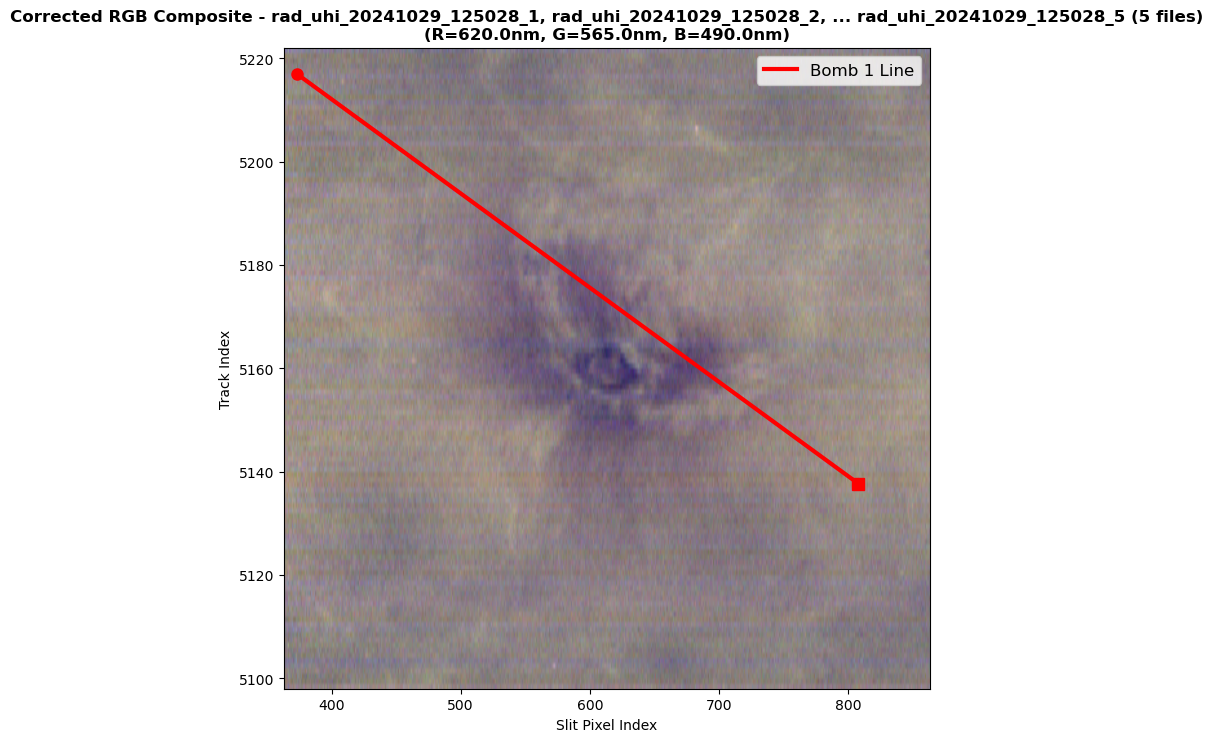


[2/5] Bomb 2
📊 Plotting RGB crop with line: Bomb 2
   Crop center: (track=1258, slit=250)
   Line (local): [(10, 65), (420, 65)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (10.0, 1260.5) → (420.0, 1260.5)


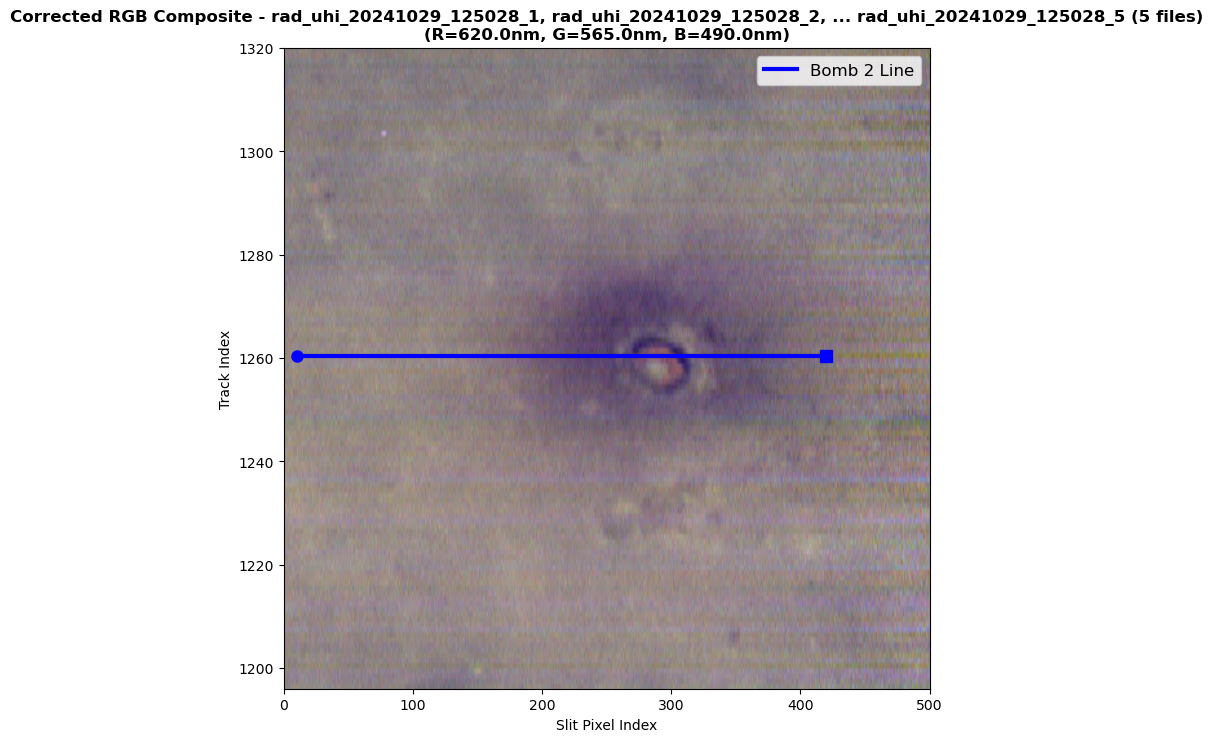


[3/5] Bomb 3
📊 Plotting RGB crop with line: Bomb 3
   Crop center: (track=5592, slit=700)
   Line (local): [(50, 65), (340, 65)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (500.0, 5594.5) → (790.0, 5594.5)


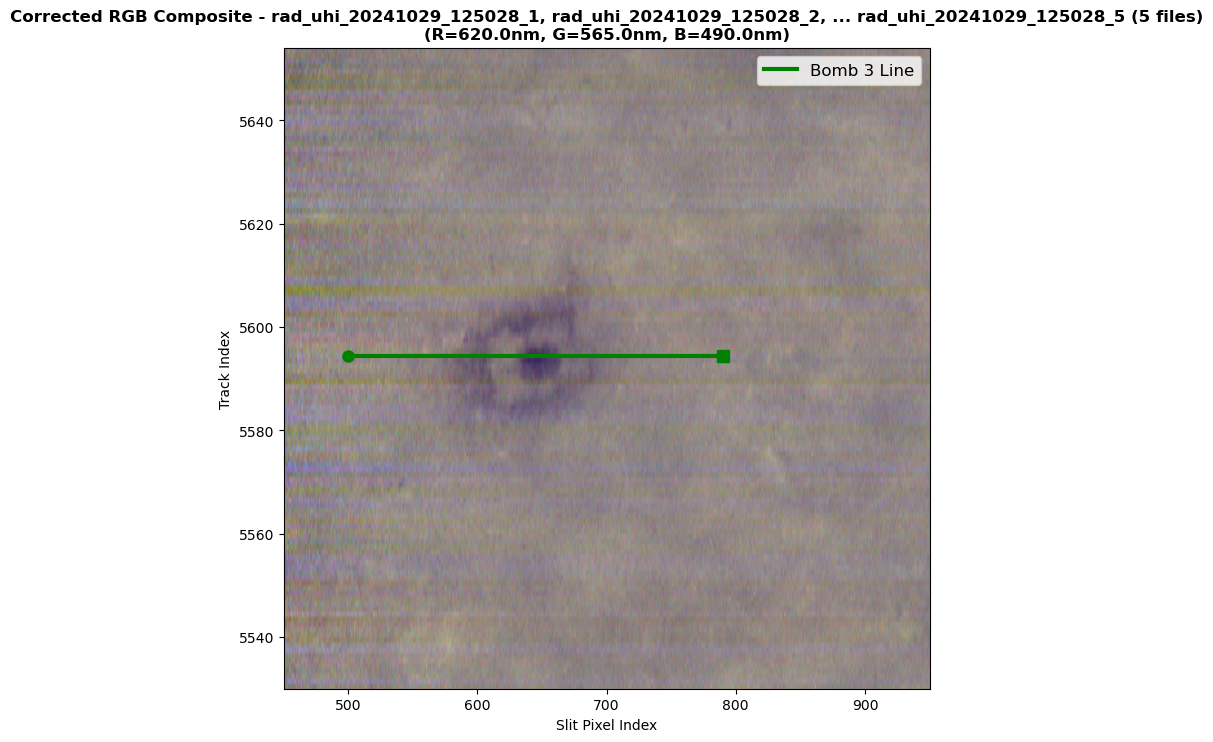


[4/5] Dark pits
📊 Plotting RGB crop with line: Dark pits
   Crop center: (track=717, slit=385)
   Line (local): [(10, 60), (410, 60)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (145.0, 714.5) → (545.0, 714.5)


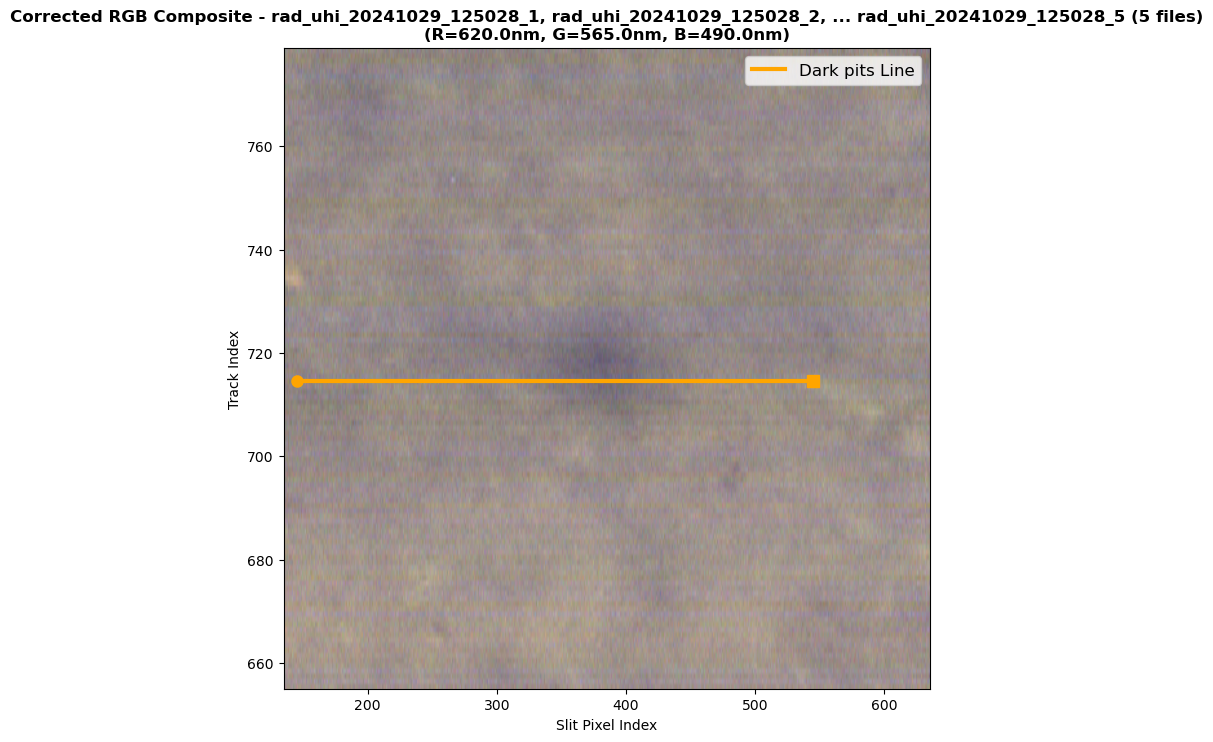


[5/5] Between 1-2
📊 Plotting RGB crop with line: Between 1-2
   Crop center: (track=4226, slit=582)
   Line (local): [(50, 60), (450, 60)]
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 4226 → local track 4226, slit 582
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [4164:4288], slit [332:832]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[332, 832], y=[4164, 4288]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
   Line (display): (382.0, 4223.5) → (782.0, 4223.5)


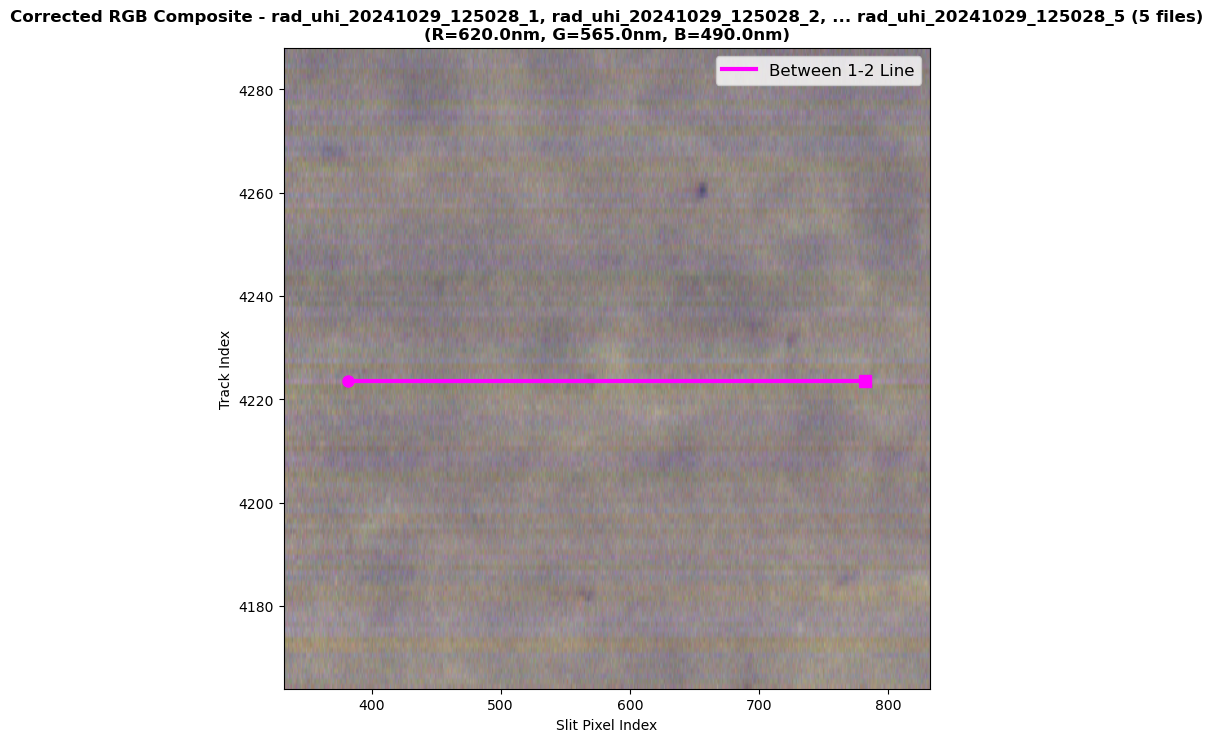


✅ Plotted all 5 RGB crops with lines!


In [52]:
# Loop through all crop regions and plot RGB crops with lines
print("=" * 80)
print("PLOTTING ALL RGB CROPS WITH LINES")
print("=" * 80)

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line = crop_lines_028[label]
    color = line_colors_028[i]

    print(f"\n[{i+1}/{len(crop_regions_028)}] {label}")

    # Plot RGB crop with line overlay (like notebook 14)
    plot_crop_with_line(
        cube_028,
        crop_region=region,
        line_local=line,
        line_color=color,
        line_width=3,
    )

print(f"\n✅ Plotted all {len(crop_regions_028)} RGB crops with lines!")

EXTRACTING INTENSITY PROFILES ALONG LINES (COMBINED PLOT)
[1/5] Bomb 1:
   Local:  [(10, 120), (445, 40)]
   Global: [(853, 5218), (418, 5138)]
   Length: 442.3 pixels
[2/5] Bomb 2:
   Local:  [(10, 65), (420, 65)]
   Global: [(490, 1261), (80, 1261)]
   Length: 410.0 pixels
[3/5] Bomb 3:
   Local:  [(50, 65), (340, 65)]
   Global: [(900, 5595), (610, 5595)]
   Length: 290.0 pixels
[4/5] Dark pits:
   Local:  [(10, 60), (410, 60)]
   Global: [(625, 715), (225, 715)]
   Length: 400.0 pixels
[5/5] Between 1-2:
   Local:  [(50, 60), (450, 60)]
   Global: [(782, 4224), (382, 4224)]
   Length: 400.0 pixels

📊 Plotting 5 intensity profiles...


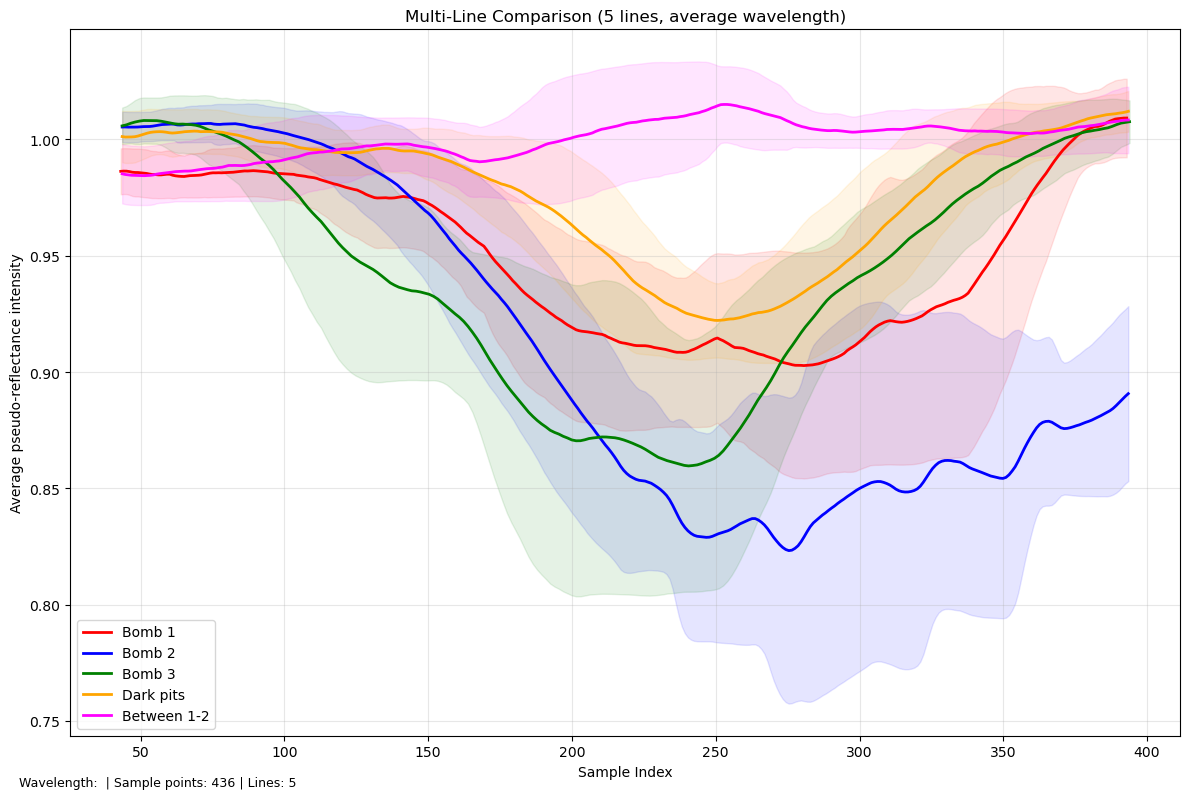


✅ Extracted intensity profiles!
   Using sparse sampling (each line at natural resolution)
   Coordinates corrected for flip_axes=True and flip_horizontal=True


In [54]:
# Extract intensity profiles for all crops - COMBINED IN ONE PLOT
# FIX: Account for flip_axes=True and flip_horizontal=True transformations
print("=" * 80)
print("EXTRACTING INTENSITY PROFILES ALONG LINES (COMBINED PLOT)")
print("=" * 80)

# Convert all local line coordinates to global coordinates
# CRITICAL: Must account for flip_axes=True and flip_horizontal=True used in plot_crop_with_line
all_lines_global = []
all_labels = []
all_colors = []

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line_local = crop_lines_028[label]
    color = line_colors_028[i]

    # Extract crop parameters
    track_center = region["track"]
    slit_center = region["slit"]
    crop_width = 500
    crop_aspect_ratio = 4
    crop_height = crop_width // crop_aspect_ratio

    # Calculate crop bounds in GLOBAL coordinates
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    # LOCAL coords are relative to the DISPLAYED image (after flip_axes and flip_horizontal)
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # CRITICAL COORDINATE TRANSFORMATION:
    # plot_crop_with_line uses flip_axes=True and flip_horizontal=True
    # flip_axes=True: swaps axes so horizontal=track, vertical=slit
    # flip_horizontal=True: mirrors horizontally (inverts x-axis)

    # After flip_axes=True:
    # - x (local horizontal, 0-500) corresponds to TRACK direction
    # - y (local vertical, 0-125) corresponds to SLIT direction

    # After flip_horizontal=True:
    # - x=0 on screen → track_max in data (right edge)
    # - x=crop_width on screen → track_min in data (left edge)
    # - So: track_global = track_max - x_local (inverted)

    # Map to global coordinates with transformations:
    # track1_global = track_center + crop_height // 2 - y1_local  # Invert y → track
    # slit1_global = slit_min + x1_local  # Direct mapping x → slit
    # track2_global = track_center + crop_height // 2 - y2_local
    # slit2_global = slit_min + x2_local

    # Map to global coordinates with transformations:
    slit1_global = (
        slit_min + crop_width - x1_local
    )  # Inverted x → slit (flip_horizontal)
    track1_global = track_min + y1_local  # Direct y → track
    slit2_global = slit_min + crop_width - x2_local
    track2_global = track_min + y2_local

    # Format: [(slit1, track1), (slit2, track2)] - matching plot_line_intensity_profile format
    line_global = [(slit1_global, track1_global), (slit2_global, track2_global)]

    # Calculate line length for diagnostic
    line_length = np.sqrt(
        (slit2_global - slit1_global) ** 2 + (track2_global - track1_global) ** 2
    )

    all_lines_global.append(line_global)
    all_labels.append(label)
    all_colors.append(color)

    print(f"[{i+1}/{len(crop_regions_028)}] {label}:")
    print(f"   Local:  {line_local}")
    print(f"   Global: {line_global}")
    print(f"   Length: {line_length:.1f} pixels")

# Plot all intensity profiles in one figure
print(f"\n📊 Plotting {len(all_lines_global)} intensity profiles...")

cube_028.plot_line_intensity_profile(
    perimeter_line=all_lines_global,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=all_labels,
    line_colors=all_colors,
    use_corrected=True,
    wavelength_range="all",
    figsize=(12, 8),
    use_sparse_sampling=True,
)

print(f"\n✅ Extracted intensity profiles!")
print(f"   Using sparse sampling (each line at natural resolution)")
print(f"   Coordinates corrected for flip_axes=True and flip_horizontal=True")

WAVELENGTH-SPECIFIC INTENSITY PROFILES

[1/5] Bomb 1
   Local: [(10, 120), (445, 40)] → Global: [(853, 5218), (418, 5138)]
📊 Auto-calculated moving average window: 4 samples (1% of 436 samples)


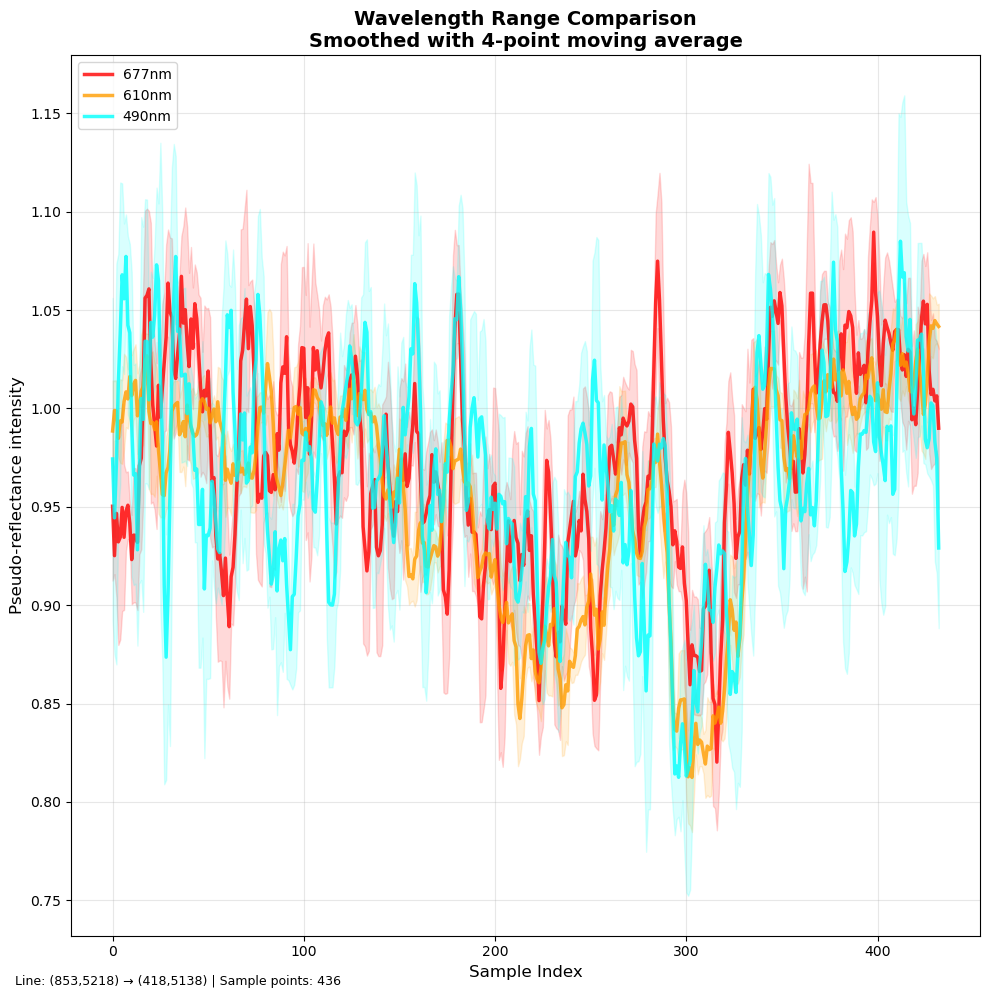


[2/5] Bomb 2
   Local: [(10, 65), (420, 65)] → Global: [(490, 1261), (80, 1261)]
📊 Auto-calculated moving average window: 4 samples (1% of 411 samples)


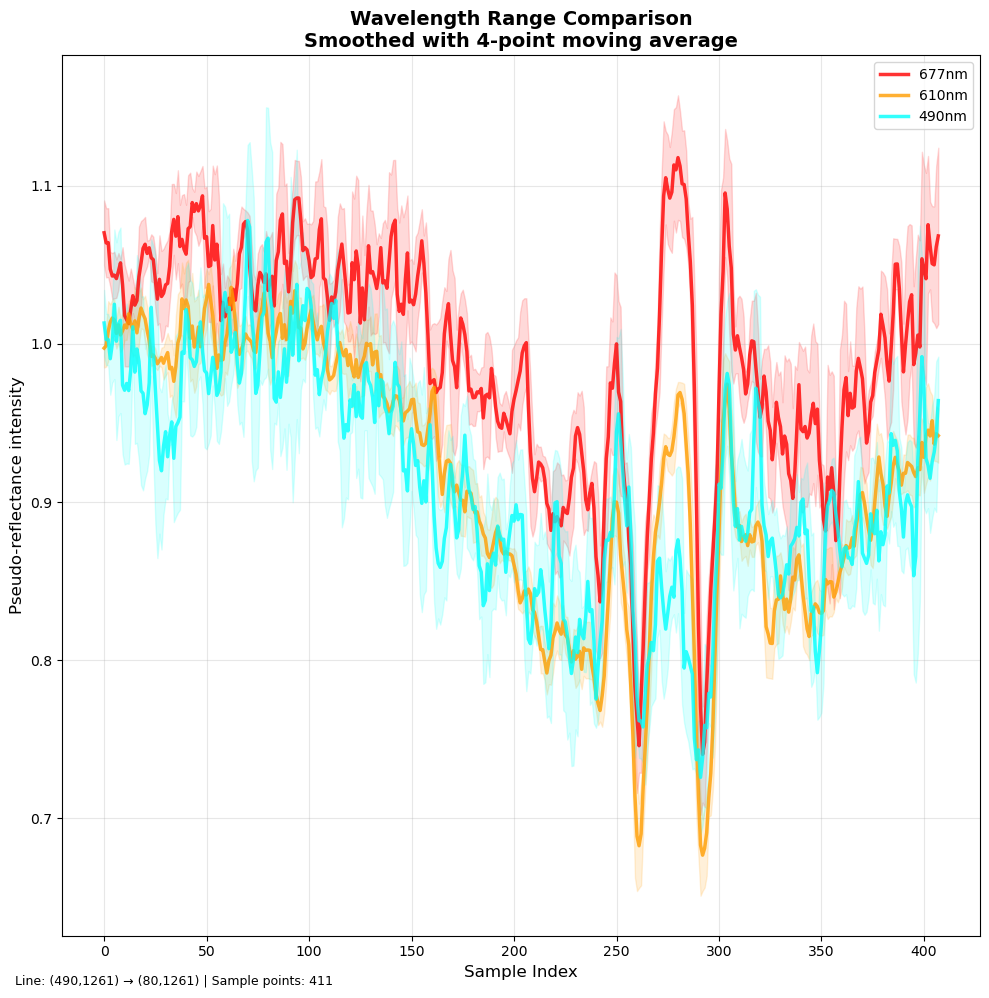


[3/5] Bomb 3
   Local: [(50, 65), (340, 65)] → Global: [(900, 5595), (610, 5595)]
📊 Auto-calculated moving average window: 2 samples (1% of 291 samples)


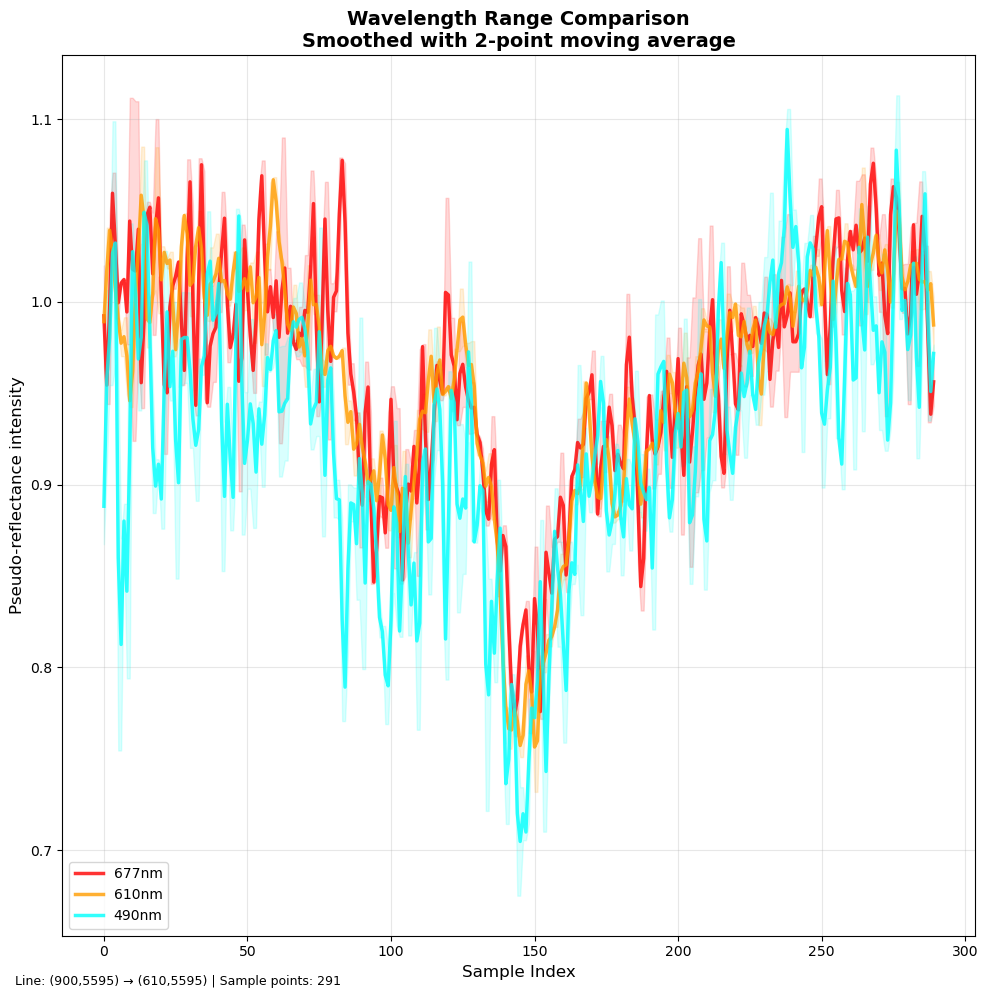


[4/5] Dark pits
   Local: [(10, 60), (410, 60)] → Global: [(625, 715), (225, 715)]
📊 Auto-calculated moving average window: 4 samples (1% of 401 samples)


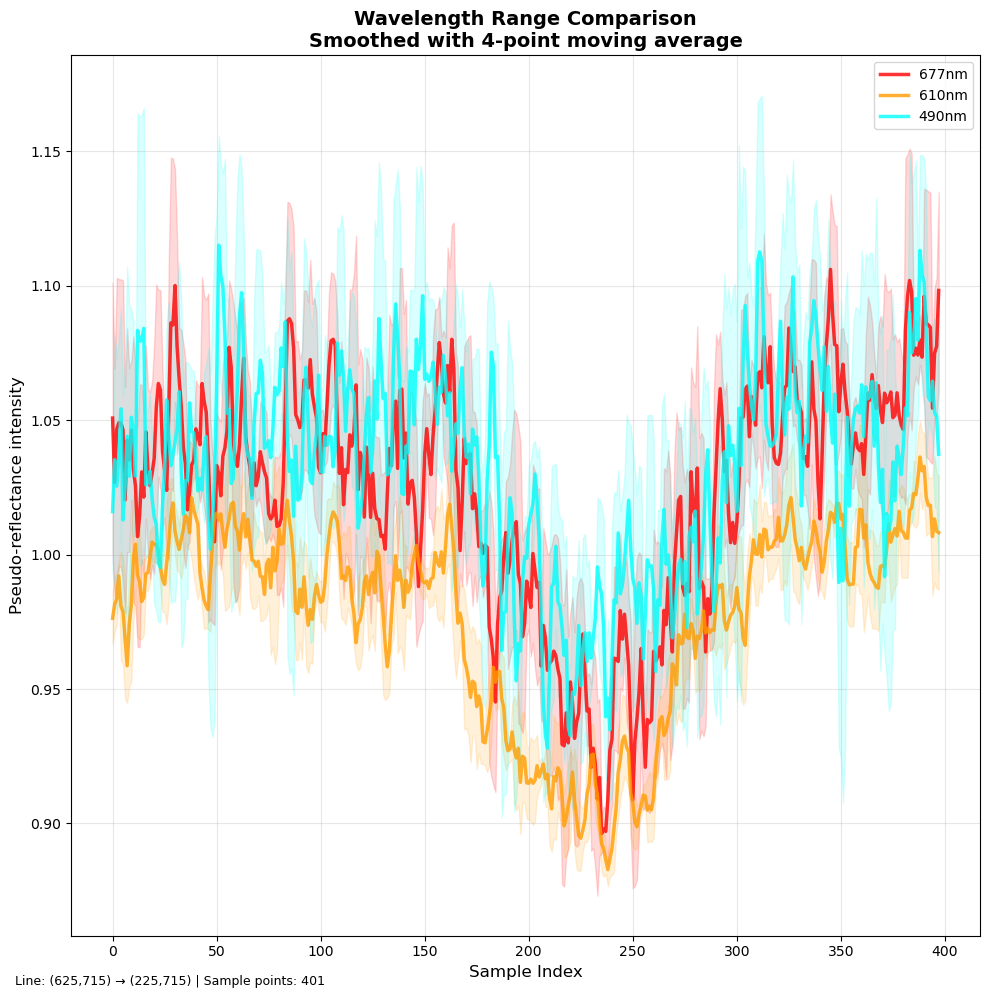


[5/5] Between 1-2
   Local: [(50, 60), (450, 60)] → Global: [(782, 4224), (382, 4224)]
📊 Auto-calculated moving average window: 4 samples (1% of 401 samples)


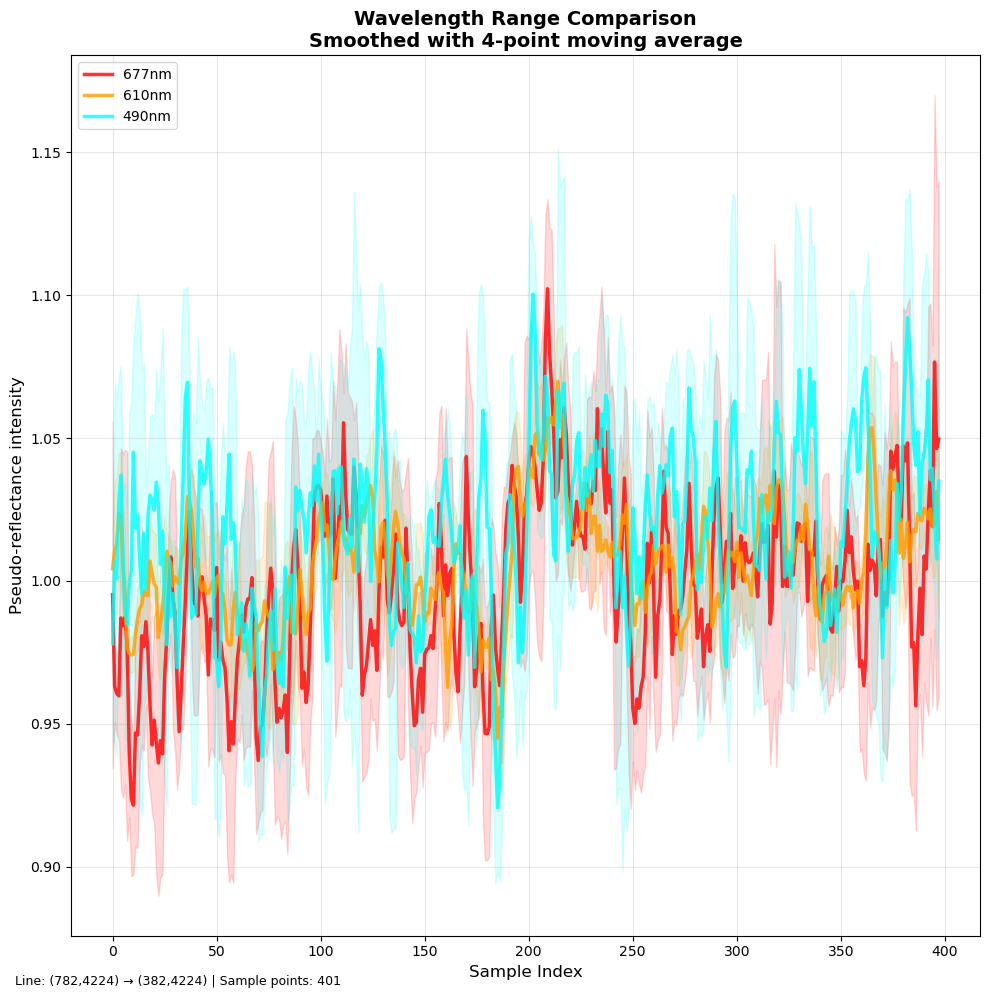


✅ Generated wavelength comparison plots for all 5 lines!


In [64]:
# Wavelength comparison for all 5 lines
print("=" * 80)
print("WAVELENGTH-SPECIFIC INTENSITY PROFILES")
print("=" * 80)

wavelengths = [677, 610, 490]  # Red, orange, cyan

for i, region in enumerate(crop_regions_028):
    label = region["label"]
    line_local = crop_lines_028[label]

    # Extract crop parameters
    track_center = region["track"]
    slit_center = region["slit"]
    crop_width = 500
    crop_aspect_ratio = 4
    crop_height = crop_width // crop_aspect_ratio

    # Calculate crop bounds in GLOBAL coordinates
    track_min = track_center - crop_height // 2
    slit_min = slit_center - crop_width // 2

    # Convert LOCAL line coordinates to GLOBAL coordinates
    # CRITICAL: Account for flip_axes=True and flip_horizontal=True
    x1_local, y1_local = line_local[0]
    x2_local, y2_local = line_local[1]

    # After transformations: x=slit (inverted), y=track (direct)
    slit1_global = slit_min + crop_width - x1_local  # Inverted (flip_horizontal)
    track1_global = track_min + y1_local  # Direct
    slit2_global = slit_min + crop_width - x2_local
    track2_global = track_min + y2_local

    # Format for plot_wavelength_comparison: [(slit1, track1), (slit2, track2)]
    line_global = [(slit1_global, track1_global), (slit2_global, track2_global)]

    print(f"\n[{i+1}/{len(crop_regions_028)}] {label}")
    print(f"   Local: {line_local} → Global: {line_global}")

    # Plot wavelength comparison
    cube_028.plot_wavelength_comparison(
        line=line_global,
        wavelength_ranges=wavelengths,
        moving_average_percent=1,
        use_corrected=True,
        figsize=(10, 10),
    )

print(
    f"\n✅ Generated wavelength comparison plots for all {len(crop_regions_028)} lines!"
)